<a href="https://colab.research.google.com/github/adamarsyadfaizin/PCVK26_10_Adam/blob/main/Week3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Moch. Adam Arsyad Faizin'
NIM = '244107020164'
N = int(NIM[-3:])

PARAM = {
    'b' : (N % 61) + 20,
    'a' : round(1.0 + (N % 9) / 10, 1),
    'c' : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit' : (N % 6) + 2,
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Moch. Adam Arsyad Faizin
NIM : 244107020164 | N = 164
b      : 62
a      : 1.2
c      : 34
gamma  : 0.9
bit    : 4
WAKTU : 2026-09-18 00:41:39 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : d8b2039806116507


# Modul 3 — Operasi Citra Sederhana

**Nama:** M. Adam Arsyad Faizin  
**NIM:** 244107020164

Parameter berdasarkan tiga digit terakhir NIM (`N = 164`):

| Parameter | Nilai |
|---|---:|
| b | 62 |
| a | 1.2 |
| c | 34 |
| gamma | 0.9 |
| bit | 4 |

In [7]:
import os, glob, math, urllib.request
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
from IPython.display import display
from google.colab import drive
from google.colab.patches import cv2_imshow

drive.mount('/content/drive')

BASE = f'/content/drive/MyDrive/PCVK/Images/{NIM}'
os.makedirs(BASE, exist_ok=True)

def read_bgr(name, flag=cv.IMREAD_COLOR):
    path = os.path.join(BASE, name)
    img = cv.imread(path, flag)
    if img is None:
        raise FileNotFoundError(path)
    return img

def bgr2rgb(img):
    return cv.cvtColor(img, cv.COLOR_BGR2RGB)

def show_grid(images, titles, cols=2, figsize=None, cmaps=None):
    n = len(images)
    rows = math.ceil(n / cols)
    if figsize is None:
        figsize = (5 * cols, 4 * rows)

    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), 1):
        ax = plt.subplot(rows, cols, i)
        cmap = None if cmaps is None else cmaps[i-1]

        if img.ndim == 3:
            if img.shape[2] == 3:
                ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                ax.imshow(img)
        else:
            ax.imshow(img, cmap=cmap if cmap else 'gray', vmin=0, vmax=255)

        ax.set_title(NIM + ' - ' + title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def psnr(img1, img2):
    a = img1.astype(np.float64)
    b = img2.astype(np.float64)
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

def clipping_mask(img):
    if img.ndim == 3:
        return np.any(img >= 255, axis=2).astype(np.uint8) * 255
    return (img >= 255).astype(np.uint8) * 255

def clip_percent(img):
    if img.ndim == 3:
        return np.mean(np.any(img >= 255, axis=2)) * 100
    return np.mean(img >= 255) * 100

def gamma_correction(img, gamma):
    x = img.astype(np.float32) / 255.0
    out = 255.0 * np.power(x, 1.0 / float(gamma))
    return np.clip(out, 0, 255).astype(np.uint8)

def edge_score(img):
    if img.ndim == 3:
        g = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    else:
        g = img
    return cv.Laplacian(g, cv.CV_64F).var()

def otsu_separability(gray):
    hist = cv.calcHist([gray], [0], None, [256], [0,256]).ravel()
    p = hist / max(hist.sum(), 1)
    levels = np.arange(256)

    omega = np.cumsum(p)
    mu = np.cumsum(p * levels)
    mu_t = mu[-1]

    denom = omega * (1.0 - omega)
    sigma_b = np.zeros_like(denom)
    valid = denom > 1e-12
    sigma_b[valid] = ((mu_t * omega[valid] - mu[valid]) ** 2) / denom[valid]

    total_var = np.sum(((levels - mu_t) ** 2) * p)
    if total_var <= 1e-12:
        return 0.0, 0

    t = int(np.argmax(sigma_b))
    eta = float(sigma_b[t] / total_var)
    return eta, t

print('BASE =', BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE = /content/drive/MyDrive/PCVK/Images/244107020164


# E. PRAKTIKUM
## E1. Operasi Citra Sederhana

### Transformasi Linier Brightness

Rumus:

\[
g(x,y)=f(x,y)+b
\]

Citra praktikum menggunakan foto **Forest Hills at dusk** dari Wikimedia Commons (CC0) sebagai `houses.jpg`.

Masukkan nilai kecerahan: 62
Brightness = 62


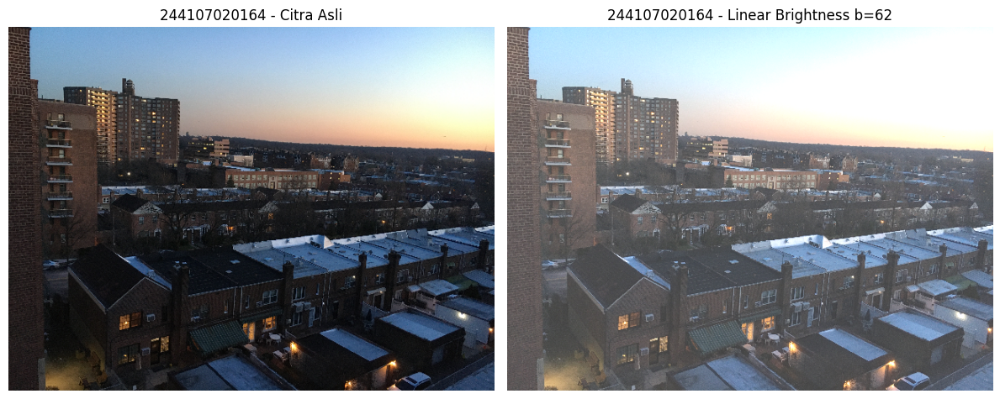

In [9]:
houses_path = os.path.join(BASE, 'houses.jpg')

if not os.path.exists(houses_path):
    urllib.request.urlretrieve(
        'https://commons.wikimedia.org/wiki/Special:Redirect/file/Forest_Hills_at_dusk.jpg',
        houses_path
    )

original = cv.imread(houses_path)
max_width = 640
if original.shape[1] > max_width:
    scale = max_width / original.shape[1]
    original = cv.resize(
        original,
        (max_width, int(original.shape[0] * scale))
    )

brightness = int(input('Masukkan nilai kecerahan: '))

brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for ch in range(original.shape[2]):
            nilai = int(original[y, x, ch]) + brightness

            if nilai > 255:
                nilai = 255
            elif nilai < 0:
                nilai = 0

            brightness_image[y, x, ch] = nilai

print('Brightness =', brightness)

show_grid(
    [original, brightness_image],
    ['Citra Asli', f'Linear Brightness b={brightness}'],
    cols=2,
    figsize=(12,5)
)

### Perbandingan `uint8 wrap-around`, `cv.add`, dan `np.clip`

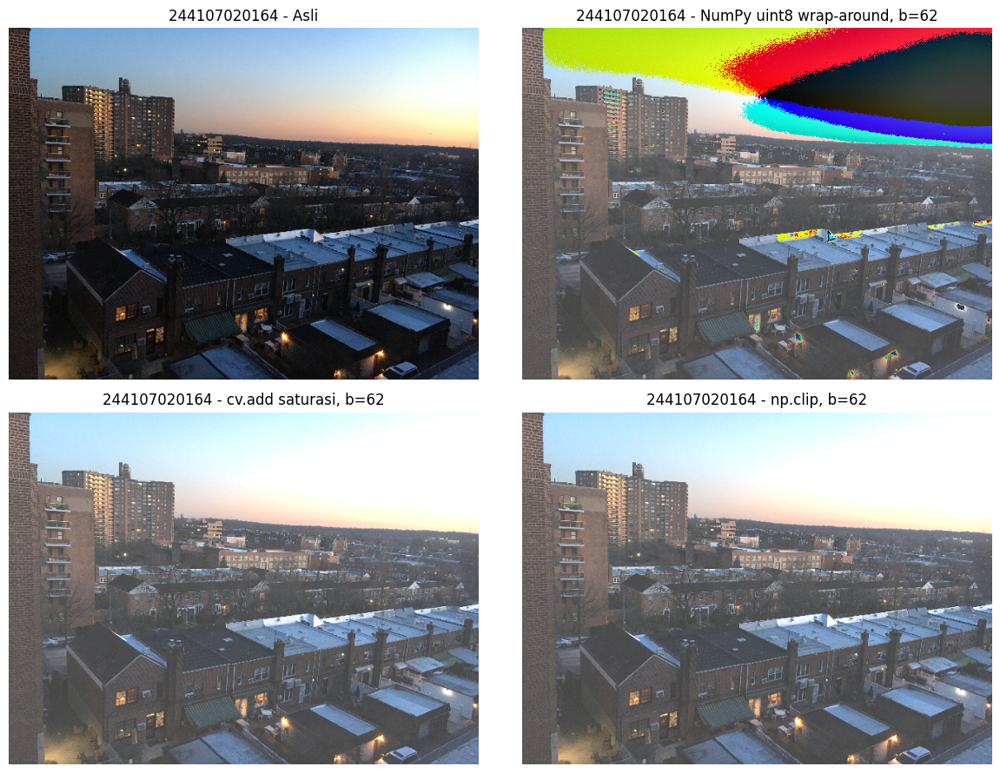

Analisis: uint8 NumPy melakukan wrap-around ketika hasil melewati 255, sedangkan cv.add dan np.clip mempertahankan nilai pada batas 255. Perbedaan paling terlihat pada bagian citra yang semula sudah terang.


In [10]:
b_praktikum = PARAM['b']

# 1) NumPy uint8: wrap-around
hasil_wrap = original + np.uint8(b_praktikum)

# 2) OpenCV: saturasi
penambah = np.full(original.shape, b_praktikum, dtype=np.uint8)
hasil_cvadd = cv.add(original, penambah)

# 3) Konversi ke int16 + clip
hasil_clip = np.clip(
    original.astype(np.int16) + b_praktikum,
    0, 255
).astype(np.uint8)

show_grid(
    [original, hasil_wrap, hasil_cvadd, hasil_clip],
    [
        'Asli',
        f'NumPy uint8 wrap-around, b={b_praktikum}',
        f'cv.add saturasi, b={b_praktikum}',
        f'np.clip, b={b_praktikum}'
    ],
    cols=2,
    figsize=(12,9)
)

print(
    'Analisis: uint8 NumPy melakukan wrap-around ketika hasil melewati 255, '
    'sedangkan cv.add dan np.clip mempertahankan nilai pada batas 255. '
    'Perbedaan paling terlihat pada bagian citra yang semula sudah terang.'
)

# TUGAS PRAKTIKUM

## 1. Inverse Citra — KTM1a dan KTM1b

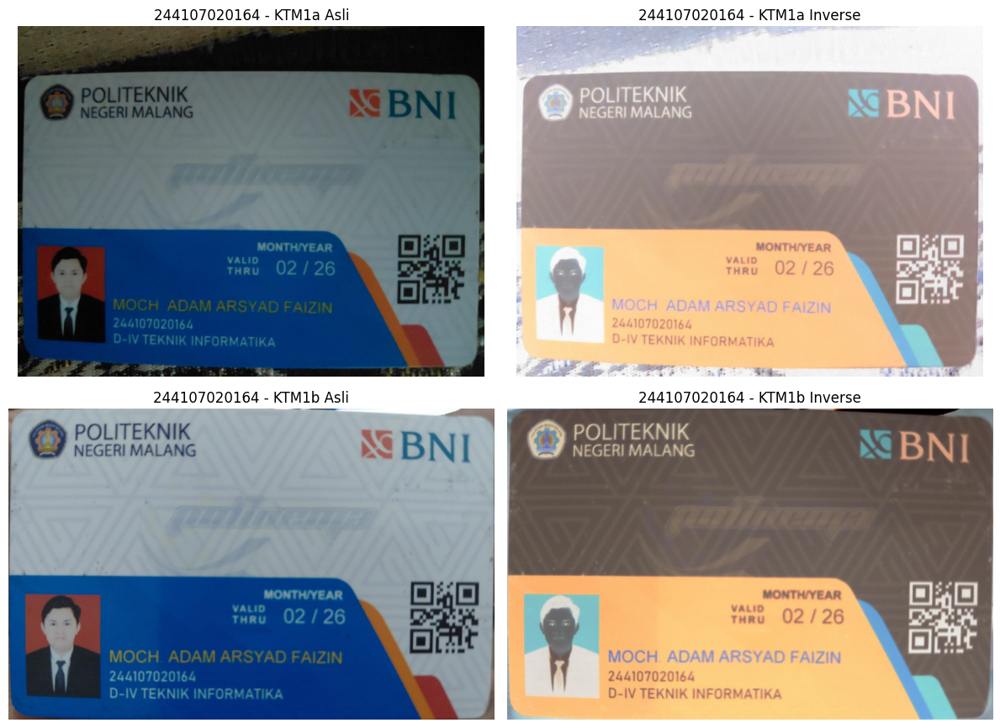

Rata-rata intensitas KTM1a = 74.46
Rata-rata intensitas KTM1b = 119.74

Analisis: KTM1a berasal dari kondisi gelap sehingga sebagian besar pixel awal bernilai rendah. Setelah inverse, nilai rendah berubah menjadi tinggi dan area gelap menjadi area terang yang luas sehingga terlihat pucat/berkabut. KTM1b memiliki sebaran intensitas awal lebih baik, sehingga negatifnya tetap menunjukkan kontras yang lebih jelas.


In [11]:
ktm1a = read_bgr('KTM1a.jpg')
ktm1b = read_bgr('KTM1b.jpg')

inverse_a = 255 - ktm1a
inverse_b = 255 - ktm1b

show_grid(
    [ktm1a, inverse_a, ktm1b, inverse_b],
    ['KTM1a Asli', 'KTM1a Inverse', 'KTM1b Asli', 'KTM1b Inverse'],
    cols=2,
    figsize=(12,9)
)

mean_a = cv.cvtColor(ktm1a, cv.COLOR_BGR2GRAY).mean()
mean_b = cv.cvtColor(ktm1b, cv.COLOR_BGR2GRAY).mean()

print(f'Rata-rata intensitas KTM1a = {mean_a:.2f}')
print(f'Rata-rata intensitas KTM1b = {mean_b:.2f}')
print()
print(
    'Analisis: KTM1a berasal dari kondisi gelap sehingga sebagian besar pixel awal '
    'bernilai rendah. Setelah inverse, nilai rendah berubah menjadi tinggi dan area gelap '
    'menjadi area terang yang luas sehingga terlihat pucat/berkabut. KTM1b memiliki '
    'sebaran intensitas awal lebih baik, sehingga negatifnya tetap menunjukkan kontras yang lebih jelas.'
)

## 2. Transformasi Contrast pada KTM1a

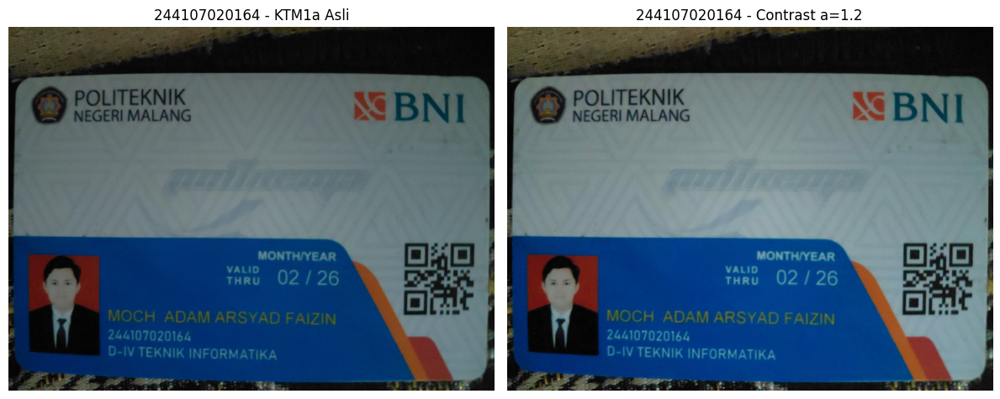

a = 1.2
Simpangan baku sebelum = 40.665
Simpangan baku sesudah = 48.769
Analisis: a > 1 memperlebar perbedaan intensitas. Kenaikan simpangan baku menunjukkan sebaran intensitas menjadi lebih lebar sehingga kontras meningkat.


In [12]:
a = PARAM['a']

contrast_img = np.clip(
    ktm1a.astype(np.float32) * a,
    0, 255
).astype(np.uint8)

show_grid(
    [ktm1a, contrast_img],
    ['KTM1a Asli', f'Contrast a={a}'],
    cols=2,
    figsize=(12,5)
)

gray_before = cv.cvtColor(ktm1a, cv.COLOR_BGR2GRAY)
gray_after = cv.cvtColor(contrast_img, cv.COLOR_BGR2GRAY)

print('a =', a)
print(f'Simpangan baku sebelum = {gray_before.std():.3f}')
print(f'Simpangan baku sesudah = {gray_after.std():.3f}')
print(
    'Analisis: a > 1 memperlebar perbedaan intensitas. '
    'Kenaikan simpangan baku menunjukkan sebaran intensitas menjadi lebih lebar sehingga kontras meningkat.'
)

## 3. Logarithmic Brightness vs Linear Brightness pada KTM1a

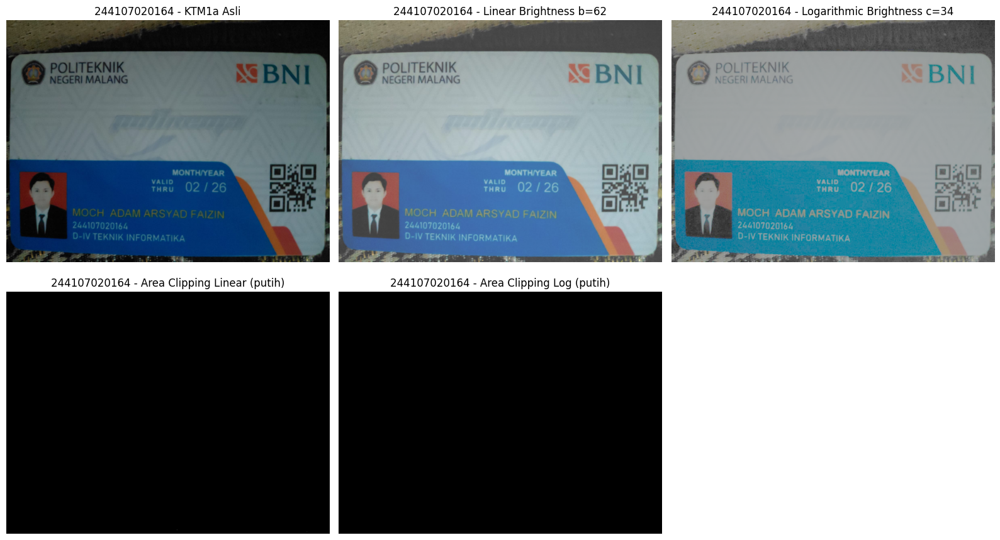

,Metode,Parameter,Rata-rata Intensitas,Simpangan Baku,Edge Score,Clipping (%)
0,Linear Brightness,b=62,136.459409,40.665094,11.756266,0.000208
1,Logarithmic Brightness,c=34,132.460705,31.832111,38.181676,0.000000


Metode yang membuat detail NIM lebih kuat berdasarkan edge-score dan clipping: Logarithmic Brightness
Clipping Linear = 0.000%
Clipping Log    = 0.000%


In [13]:
b = PARAM['b']
c_log = PARAM['c']

linear_img = np.clip(
    ktm1a.astype(np.int16) + b,
    0, 255
).astype(np.uint8)

log_img = np.clip(
    c_log * np.log1p(ktm1a.astype(np.float32)),
    0, 255
).astype(np.uint8)

linear_clip = clipping_mask(linear_img)
log_clip = clipping_mask(log_img)

show_grid(
    [ktm1a, linear_img, log_img, linear_clip, log_clip],
    [
        'KTM1a Asli',
        f'Linear Brightness b={b}',
        f'Logarithmic Brightness c={c_log}',
        'Area Clipping Linear (putih)',
        'Area Clipping Log (putih)'
    ],
    cols=3,
    figsize=(16,9),
    cmaps=[None,None,None,'gray','gray']
)

data_t3 = pd.DataFrame({
    'Metode': ['Linear Brightness', 'Logarithmic Brightness'],
    'Parameter': [f'b={b}', f'c={c_log}'],
    'Rata-rata Intensitas': [
        cv.cvtColor(linear_img, cv.COLOR_BGR2GRAY).mean(),
        cv.cvtColor(log_img, cv.COLOR_BGR2GRAY).mean()
    ],
    'Simpangan Baku': [
        cv.cvtColor(linear_img, cv.COLOR_BGR2GRAY).std(),
        cv.cvtColor(log_img, cv.COLOR_BGR2GRAY).std()
    ],
    'Edge Score': [
        edge_score(linear_img),
        edge_score(log_img)
    ],
    'Clipping (%)': [
        clip_percent(linear_img),
        clip_percent(log_img)
    ]
})
display(data_t3)

# Keterbacaan dipilih dari detail tepi dan penalti clipping.
score_linear = data_t3.loc[0, 'Edge Score'] * (1 - data_t3.loc[0, 'Clipping (%)'] / 100)
score_log = data_t3.loc[1, 'Edge Score'] * (1 - data_t3.loc[1, 'Clipping (%)'] / 100)

metode_t3 = 'Linear Brightness' if score_linear >= score_log else 'Logarithmic Brightness'

print('Metode yang membuat detail NIM lebih kuat berdasarkan edge-score dan clipping:', metode_t3)
print(f'Clipping Linear = {data_t3.loc[0, "Clipping (%)"]:.3f}%')
print(f'Clipping Log    = {data_t3.loc[1, "Clipping (%)"]:.3f}%')

## 4. Grayscale Averaging, Lightness, dan Luminance pada KTM1c

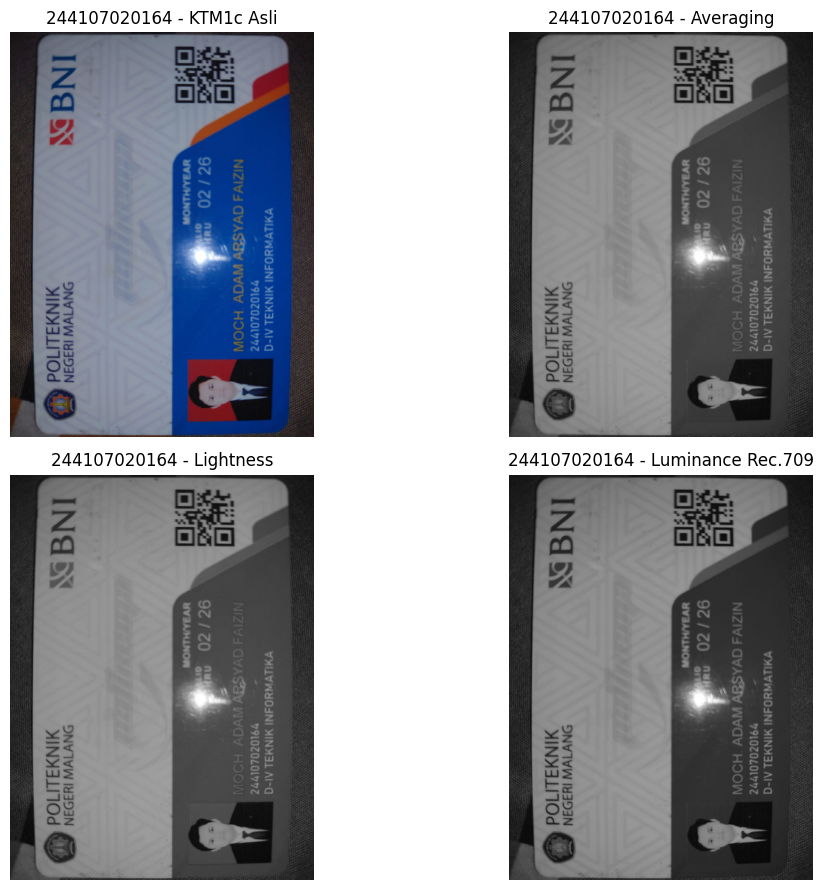

,Metode,Rata-rata Intensitas,Simpangan Baku,Threshold Otsu,Separabilitas Teks-Latar
0,Averaging,98.227085,45.394816,96,0.865525
1,Lightness,100.867656,44.774669,99,0.845807
2,Luminance Rec.709,91.905464,47.395664,90,0.897324


Metode dengan pemisahan teks-latar paling jelas: Luminance Rec.709


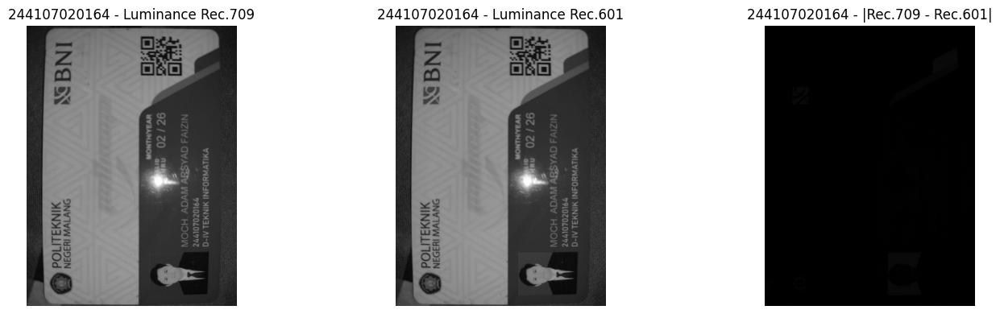

Rata-rata selisih absolut Rec.709 dan Rec.601 = 0.724


In [14]:
ktm1c = read_bgr('KTM1c.jpg')
rgb = cv.cvtColor(ktm1c, cv.COLOR_BGR2RGB).astype(np.float32)
R, G, B = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]

gray_avg = np.clip((R + G + B) / 3.0, 0, 255).astype(np.uint8)
gray_lightness = np.clip(
    (np.maximum.reduce([R,G,B]) + np.minimum.reduce([R,G,B])) / 2.0,
    0, 255
).astype(np.uint8)

# Rec.709 sesuai rumus pada modul
gray_lum709 = np.clip(
    0.21*R + 0.72*G + 0.07*B,
    0, 255
).astype(np.uint8)

# Rec.601 sebagai pembanding sesuai catatan modul
gray_lum601 = np.clip(
    0.299*R + 0.587*G + 0.114*B,
    0, 255
).astype(np.uint8)

show_grid(
    [ktm1c, gray_avg, gray_lightness, gray_lum709],
    ['KTM1c Asli', 'Averaging', 'Lightness', 'Luminance Rec.709'],
    cols=2,
    figsize=(12,9),
    cmaps=[None,'gray','gray','gray']
)

metode = {
    'Averaging': gray_avg,
    'Lightness': gray_lightness,
    'Luminance Rec.709': gray_lum709
}

rows = []
for nama, img in metode.items():
    eta, threshold = otsu_separability(img)
    rows.append([
        nama,
        float(img.mean()),
        float(img.std()),
        threshold,
        eta
    ])

df_gray = pd.DataFrame(
    rows,
    columns=[
        'Metode',
        'Rata-rata Intensitas',
        'Simpangan Baku',
        'Threshold Otsu',
        'Separabilitas Teks-Latar'
    ]
)
display(df_gray)

best_gray = df_gray.loc[df_gray['Separabilitas Teks-Latar'].idxmax(), 'Metode']
print('Metode dengan pemisahan teks-latar paling jelas:', best_gray)

selisih_709_601 = cv.absdiff(gray_lum709, gray_lum601)
show_grid(
    [gray_lum709, gray_lum601, selisih_709_601],
    ['Luminance Rec.709', 'Luminance Rec.601', '|Rec.709 - Rec.601|'],
    cols=3,
    figsize=(15,4),
    cmaps=['gray','gray','gray']
)

print(f'Rata-rata selisih absolut Rec.709 dan Rec.601 = {selisih_709_601.mean():.3f}')

## 5. Satu Warna Dipertahankan, Bagian Lain Grayscale — OBJ1

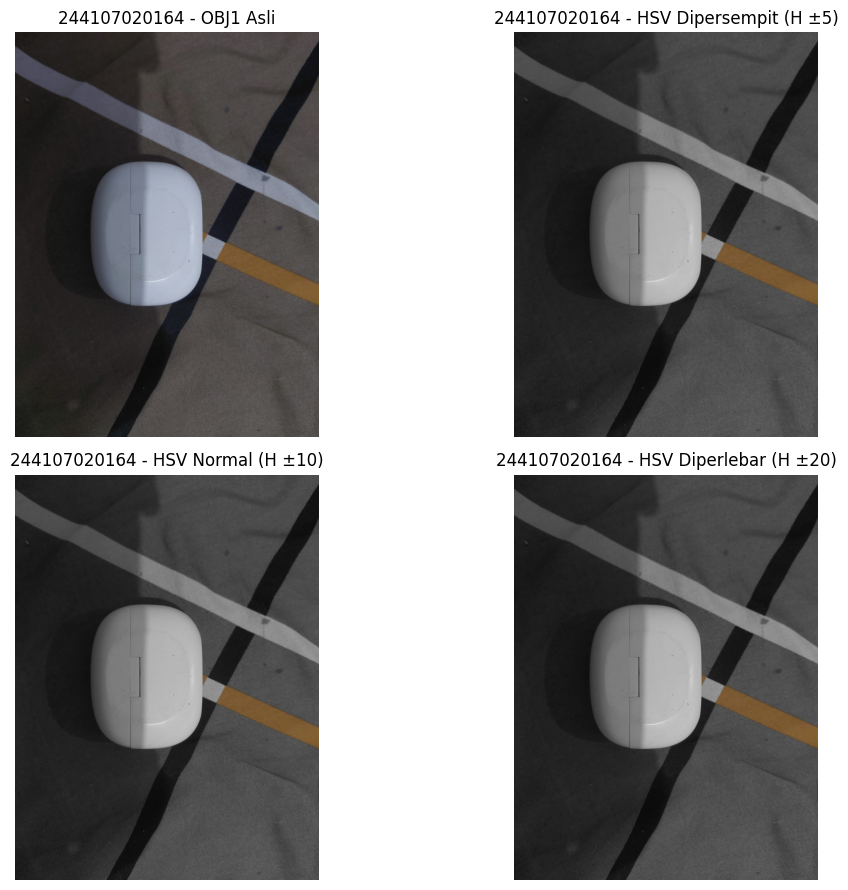

,Percobaan,H,S minimum,V minimum,Pixel warna dipertahankan (%)
0,Dipersempit,17 ± 5,60,40,1.907240
1,Normal,17 ± 10,60,40,1.917135
2,Diperlebar,17 ± 20,60,40,1.917708


Hue dominan = 17
Analisis: rentang sempit lebih selektif tetapi dapat membuang bagian objek yang hue-nya berubah karena bayangan/cahaya. Rentang lebar mempertahankan lebih banyak bagian objek tetapi lebih berisiko mengikutkan warna latar yang mirip.


In [15]:
obj = read_bgr('OBJ1.jpg')
hsv = cv.cvtColor(obj, cv.COLOR_BGR2HSV)

H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

valid = (S >= 70) & (V >= 50)
if np.any(valid):
    hist = np.bincount(H[valid].ravel(), weights=S[valid].ravel(), minlength=180)
    hue_dominan = int(np.argmax(hist))
else:
    hue_dominan = int(np.median(H))

def hsv_mask_circular(h, s, v, center, delta, smin=60, vmin=40):
    d = np.minimum((h-center) % 180, (center-h) % 180)
    return ((d <= delta) & (s >= smin) & (v >= vmin)).astype(np.uint8) * 255

def color_splash(img_bgr, mask):
    gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    gray3 = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)
    return np.where(mask[:,:,None] == 255, img_bgr, gray3)

mask_sempit = hsv_mask_circular(H,S,V,hue_dominan,5)
mask_normal = hsv_mask_circular(H,S,V,hue_dominan,10)
mask_lebar = hsv_mask_circular(H,S,V,hue_dominan,20)

splash_sempit = color_splash(obj, mask_sempit)
splash_normal = color_splash(obj, mask_normal)
splash_lebar = color_splash(obj, mask_lebar)

show_grid(
    [obj, splash_sempit, splash_normal, splash_lebar],
    [
        'OBJ1 Asli',
        'HSV Dipersempit (H ±5)',
        'HSV Normal (H ±10)',
        'HSV Diperlebar (H ±20)'
    ],
    cols=2,
    figsize=(12,9)
)

df_hsv = pd.DataFrame({
    'Percobaan': ['Dipersempit', 'Normal', 'Diperlebar'],
    'H': [
        f'{hue_dominan} ± 5',
        f'{hue_dominan} ± 10',
        f'{hue_dominan} ± 20'
    ],
    'S minimum': [60,60,60],
    'V minimum': [40,40,40],
    'Pixel warna dipertahankan (%)': [
        np.mean(mask_sempit == 255) * 100,
        np.mean(mask_normal == 255) * 100,
        np.mean(mask_lebar == 255) * 100
    ]
})
display(df_hsv)

print('Hue dominan =', hue_dominan)
print(
    'Analisis: rentang sempit lebih selektif tetapi dapat membuang bagian objek yang hue-nya berubah '
    'karena bayangan/cahaya. Rentang lebar mempertahankan lebih banyak bagian objek tetapi lebih berisiko '
    'mengikutkan warna latar yang mirip.'
)

## 6. Gamma Correction pada KTM1a

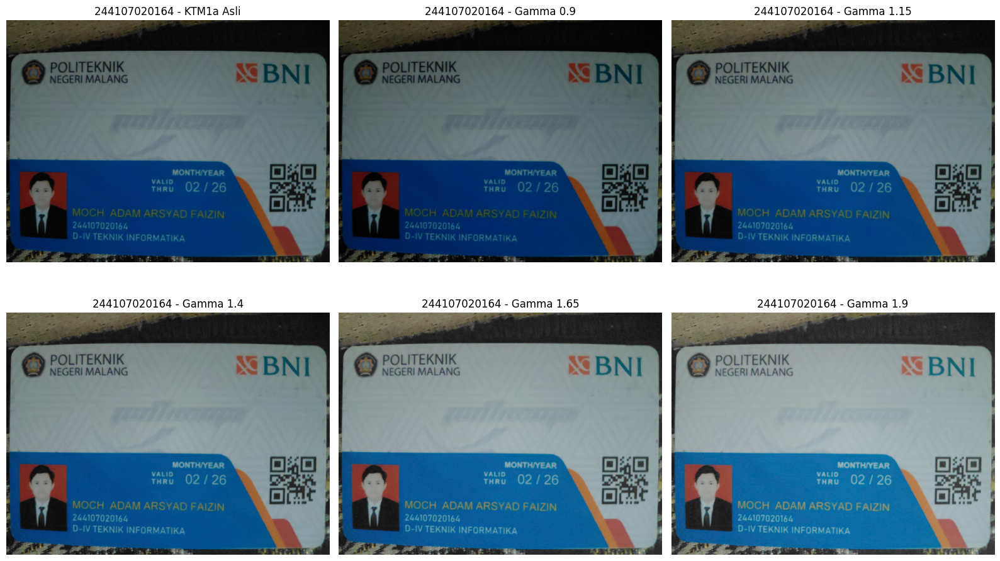

,Gamma,Mean,Std,Edge Score,Clipping (%),Skor Keterbacaan
0,0.90,66.315345,38.502241,10.698600,0.0,7.391741
1,1.15,84.458545,43.035751,14.605032,0.0,11.267760
2,1.40,99.617250,45.299484,18.432901,0.0,15.756552
3,1.65,112.280233,46.181947,22.264397,0.0,20.918670
4,1.90,122.955278,46.052729,26.339100,0.0,25.706029


Gamma awal dari NIM = 0.9
Gamma terbaik = 1.9
Nilai terbaik dapat berbeda antar mahasiswa karena exposure, intensitas lampu, pantulan kartu, sensor kamera, dan histogram citra awal masing-masing berbeda.


In [16]:
gamma_awal = PARAM['gamma']

# Mulai dari gamma NIM lalu dinaikkan bertahap karena KTM1a merupakan citra gelap.
daftar_gamma = [
    round(gamma_awal + 0.00, 2),
    round(gamma_awal + 0.25, 2),
    round(gamma_awal + 0.50, 2),
    round(gamma_awal + 0.75, 2),
    round(gamma_awal + 1.00, 2)
]

gamma_results = [gamma_correction(ktm1a, g) for g in daftar_gamma]

show_grid(
    [ktm1a] + gamma_results,
    ['KTM1a Asli'] + [f'Gamma {g}' for g in daftar_gamma],
    cols=3,
    figsize=(16,10)
)

rows = []
for g, img in zip(daftar_gamma, gamma_results):
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    clipping = clip_percent(img)
    edges = edge_score(img)
    # Skor: detail tinggi, clipping rendah, dan citra tidak terlalu gelap/terang.
    brightness_penalty = abs(float(gray.mean()) - 120.0)
    score = edges * (1 - clipping/100.0) / (1 + brightness_penalty/120.0)
    rows.append([g, gray.mean(), gray.std(), edges, clipping, score])

df_gamma = pd.DataFrame(
    rows,
    columns=['Gamma', 'Mean', 'Std', 'Edge Score', 'Clipping (%)', 'Skor Keterbacaan']
)
display(df_gamma)

idx_best = df_gamma['Skor Keterbacaan'].idxmax()
gamma_terbaik = float(df_gamma.loc[idx_best, 'Gamma'])

print('Gamma awal dari NIM =', gamma_awal)
print('Gamma terbaik =', gamma_terbaik)
print(
    'Nilai terbaik dapat berbeda antar mahasiswa karena exposure, intensitas lampu, pantulan kartu, '
    'sensor kamera, dan histogram citra awal masing-masing berbeda.'
)

## 7. Simulasi Image Depth 1–7 Bit pada KTM1b

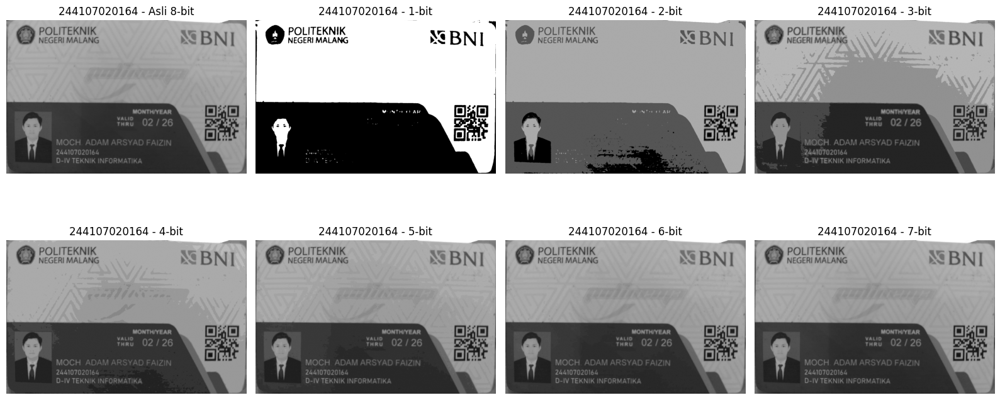

,Bit Depth,Jumlah Level,Jarak Antar Level,PSNR (dB),Retensi Tepi
0,1,2,255.000000,9.839898,0.584051
1,2,4,85.000000,20.879215,1.067873
2,3,8,36.428571,26.725755,2.718586
3,4,16,17.000000,34.485482,0.835430
4,5,32,8.225806,40.788928,0.997377
5,6,64,4.047619,46.155102,0.988733
6,7,128,2.007874,51.102454,0.975044


Bit depth paling rendah saat nama dan NIM masih dipertahankan dengan baik = 2 bit
Bit depth dari parameter NIM = 4 bit


In [17]:
original_depth = read_bgr('KTM1b.jpg', cv.IMREAD_GRAYSCALE)

depth_imgs = []
depth_rows = []

edge_original = cv.Canny(original_depth, 70, 140)
edge_original_count = max(np.count_nonzero(edge_original), 1)

for bit_depth in range(1, 8):
    level = 255 / (pow(2, bit_depth) - 1)
    depth_image = np.round(original_depth / level) * level
    depth_image = np.clip(depth_image, 0, 255).astype(np.uint8)

    edge_q = cv.Canny(depth_image, 70, 140)
    edge_retention = np.count_nonzero(edge_q) / edge_original_count

    depth_imgs.append(depth_image)
    depth_rows.append([
        bit_depth,
        2**bit_depth,
        level,
        psnr(original_depth, depth_image),
        edge_retention
    ])

show_grid(
    [original_depth] + depth_imgs,
    ['Asli 8-bit'] + [f'{b}-bit' for b in range(1,8)],
    cols=4,
    figsize=(16,8),
    cmaps=['gray']*8
)

df_depth = pd.DataFrame(
    depth_rows,
    columns=[
        'Bit Depth',
        'Jumlah Level',
        'Jarak Antar Level',
        'PSNR (dB)',
        'Retensi Tepi'
    ]
)
display(df_depth)

# Ambang keterbacaan objektif: PSNR >= 20 dB dan >= 70% struktur tepi masih tertangkap.
layak = df_depth[
    (df_depth['PSNR (dB)'] >= 20) &
    (df_depth['Retensi Tepi'] >= 0.70)
]

if len(layak):
    bit_terbaca = int(layak.iloc[0]['Bit Depth'])
else:
    bit_terbaca = int(df_depth.iloc[-1]['Bit Depth'])

print('Bit depth paling rendah saat nama dan NIM masih dipertahankan dengan baik =', bit_terbaca, 'bit')
print('Bit depth dari parameter NIM =', PARAM['bit'], 'bit')

## 8. Average Denoising dan PSNR

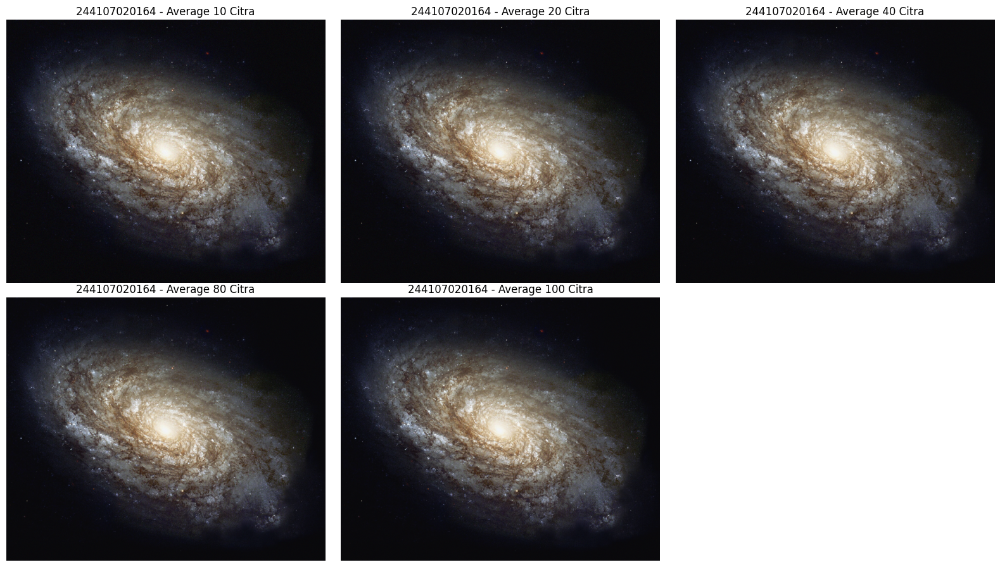

,Jumlah Citra di-Average,PSNR (dB),Kenaikan PSNR (dB)
0,10,29.736612,NaN
1,20,31.384286,1.647674
2,40,32.522757,1.138471
3,80,33.225116,0.702359
4,100,33.380680,0.155564


Sumber noise: 100 Gaussian noise fallback (sigma=25, seed=NIM)
Peningkatan mulai tidak terlalu signifikan pada sekitar 80 citra.
Kesimpulan: penambahan jumlah citra rata-rata meningkatkan PSNR karena noise acak saling mereduksi, tetapi tambahan manfaat makin kecil ketika jumlah citra sudah besar.


In [18]:
galaxy = read_bgr('galaxy.jpg')

candidate_noise_dirs = [
    os.path.join(BASE, 'noises'),
    '/content/drive/MyDrive/PCVK/Images/noises',
    '/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/noises'
]

noise_paths = []
for folder in candidate_noise_dirs:
    found = sorted(glob.glob(os.path.join(folder, '*.jpg')))
    if len(found) >= 100:
        noise_paths = found[:100]
        break

noise_images = []

if len(noise_paths) >= 100:
    for path in noise_paths[:100]:
        img = cv.imread(path)
        if img is not None:
            if img.shape[:2] != galaxy.shape[:2]:
                img = cv.resize(img, (galaxy.shape[1], galaxy.shape[0]))
            noise_images.append(img)
    sumber_noise = '100 citra Gaussian noise dari folder noises'
else:
    # Fallback hanya ketika paket noises dari modul memang tidak terdapat pada Drive.
    rng = np.random.default_rng(N)
    sigma = 25.0
    for i in range(100):
        n = rng.normal(0, sigma, galaxy.shape).astype(np.float32)
        noisy = np.clip(galaxy.astype(np.float32) + n, 0, 255).astype(np.uint8)
        noise_images.append(noisy)
    sumber_noise = '100 Gaussian noise fallback (sigma=25, seed=NIM)'

jumlah_average = [10, 20, 40, 80, 100]
average_imgs = []
psnr_rows = []

for n_img in jumlah_average:
    stack = np.stack(noise_images[:n_img], axis=0).astype(np.float32)
    averaged = np.mean(stack, axis=0)
    averaged = np.clip(averaged, 0, 255).astype(np.uint8)

    nilai_psnr = psnr(galaxy, averaged)

    average_imgs.append(averaged)
    psnr_rows.append([n_img, nilai_psnr])

show_grid(
    average_imgs,
    [f'Average {n} Citra' for n in jumlah_average],
    cols=3,
    figsize=(16,9)
)

df_psnr = pd.DataFrame(
    psnr_rows,
    columns=['Jumlah Citra di-Average', 'PSNR (dB)']
)
df_psnr['Kenaikan PSNR (dB)'] = df_psnr['PSNR (dB)'].diff()
display(df_psnr)

# Definisi praktis "tidak terlalu signifikan": tambahan PSNR < 1 dB dibanding tahap sebelumnya.
melandai = df_psnr[
    df_psnr['Kenaikan PSNR (dB)'].notna() &
    (df_psnr['Kenaikan PSNR (dB)'] < 1.0)
]

print('Sumber noise:', sumber_noise)

if len(melandai):
    mulai_melandai = int(melandai.iloc[0]['Jumlah Citra di-Average'])
    print('Peningkatan mulai tidak terlalu signifikan pada sekitar', mulai_melandai, 'citra.')
else:
    print('Pada titik pengujian 10–100 citra, kenaikan tiap tahap masih >= 1 dB.')

print(
    'Kesimpulan: penambahan jumlah citra rata-rata meningkatkan PSNR karena noise acak saling mereduksi, '
    'tetapi tambahan manfaat makin kecil ketika jumlah citra sudah besar.'
)

## 9. Image Masking untuk Penyamaran Data Pribadi

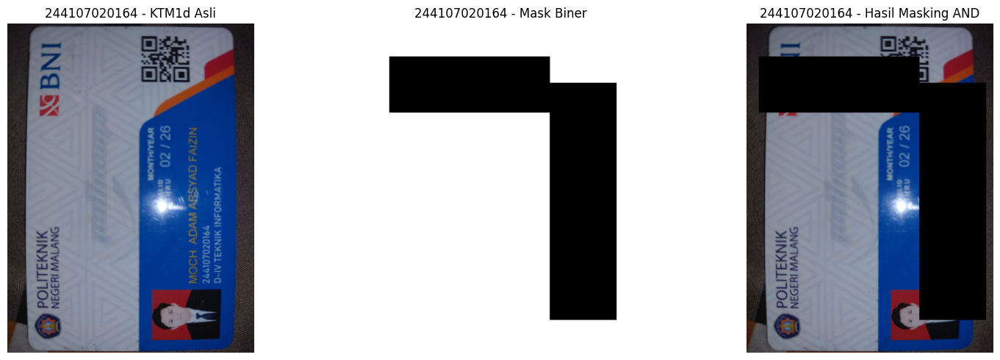

Koordinat kotak foto wajah = (840, 288, 1164, 1440)
Koordinat kotak NIM        = (60, 160, 840, 432)


In [20]:
ktm1d = read_bgr('KTM1d.jpg')
h, w = ktm1d.shape[:2]

FACE_BOX = (
    int(0.70 * w),   # x1
    int(0.18 * h),   # y1
    int(0.97 * w),   # x2
    int(0.90 * h)    # y2
)

# Area NIM pada KTM
NIM_BOX = (
    int(0.05 * w),   # x1
    int(0.10 * h),   # y1
    int(0.70 * w),   # x2
    int(0.27 * h)    # y2
)

mask = np.full((h, w), 255, dtype=np.uint8)

x1, y1, x2, y2 = FACE_BOX
cv.rectangle(
    mask,
    (x1, y1),
    (x2, y2),
    0,
    thickness=-1
)

x1, y1, x2, y2 = NIM_BOX
cv.rectangle(
    mask,
    (x1, y1),
    (x2, y2),
    0,
    thickness=-1
)

mask3 = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
hasil_and = cv.bitwise_and(
    ktm1d,
    mask3
)

show_grid(
    [ktm1d, mask, hasil_and],
    [
        'KTM1d Asli',
        'Mask Biner',
        'Hasil Masking AND'
    ],
    cols=3,
    figsize=(16, 5),
    cmaps=[None, 'gray', None]
)

print('Koordinat kotak foto wajah =', FACE_BOX)
print('Koordinat kotak NIM        =', NIM_BOX)

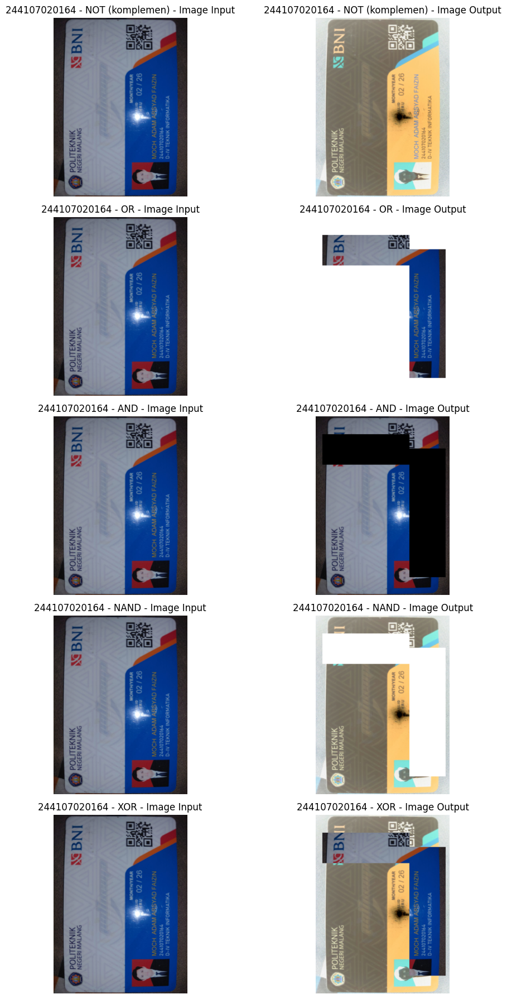

Analisis:
NOT membalik seluruh bit citra sehingga warna menjadi komplemennya.
OR dengan mask putih membuat area mask menjadi putih.
AND dengan mask hitam membuat area wajah dan NIM menjadi hitam sehingga tersamarkan.
NAND adalah komplemen dari hasil AND.
XOR mempertahankan nilai pada area mask 0 dan membalik bit pada area mask 255.


In [21]:
hasil_not = cv.bitwise_not(ktm1d)
hasil_or = cv.bitwise_or(ktm1d, mask3)
hasil_nand = cv.bitwise_not(cv.bitwise_and(ktm1d, mask3))
hasil_xor = cv.bitwise_xor(ktm1d, mask3)

ops = [
    ('NOT (komplemen)', ktm1d, hasil_not),
    ('OR', ktm1d, hasil_or),
    ('AND', ktm1d, hasil_and),
    ('NAND', ktm1d, hasil_nand),
    ('XOR', ktm1d, hasil_xor),
]

plt.figure(figsize=(12, 18))

for i, (nama, inp, outp) in enumerate(ops):
    ax1 = plt.subplot(5, 2, 2*i + 1)
    ax1.imshow(cv.cvtColor(inp, cv.COLOR_BGR2RGB))
    ax1.set_title(NIM + ' - ' + nama + ' - Image Input')
    ax1.axis('off')

    ax2 = plt.subplot(5, 2, 2*i + 2)
    ax2.imshow(cv.cvtColor(outp, cv.COLOR_BGR2RGB))
    ax2.set_title(NIM + ' - ' + nama + ' - Image Output')
    ax2.axis('off')

plt.tight_layout()
plt.show()

print(
    'Analisis:\n'
    'NOT membalik seluruh bit citra sehingga warna menjadi komplemennya.\n'
    'OR dengan mask putih membuat area mask menjadi putih.\n'
    'AND dengan mask hitam membuat area wajah dan NIM menjadi hitam sehingga tersamarkan.\n'
    'NAND adalah komplemen dari hasil AND.\n'
    'XOR mempertahankan nilai pada area mask 0 dan membalik bit pada area mask 255.'
)

## 10. Perbaikan Foto Malam Hari — NIGHT1

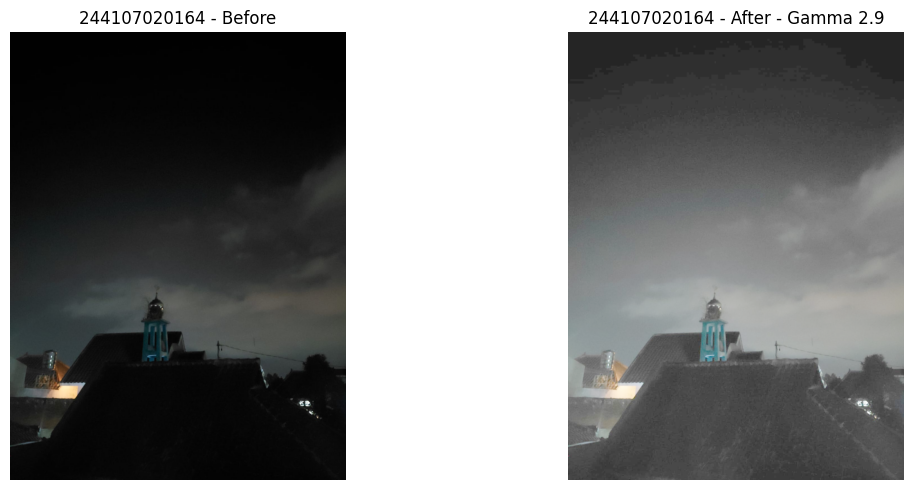

,Gamma,Mean,Std,Edge Score,Clipping (%),Skor
12,2.90,99.980946,42.331096,18.907142,0.048281,18.035889
11,2.75,95.524780,42.464096,18.512430,0.048281,16.971941
10,2.60,90.861578,42.482146,18.335200,0.048281,16.151519
9,2.45,85.899266,42.459602,18.289733,0.048281,15.467232
8,2.30,80.549504,42.350685,17.961031,0.048281,14.561533
7,2.15,75.088598,42.016411,17.493897,0.048281,13.608726
6,2.00,69.385940,41.425212,16.859420,0.048281,12.583268
5,1.85,63.416598,40.603009,16.122812,0.048281,11.543449
4,1.70,57.177395,39.468034,15.127391,0.048281,10.388576
3,1.55,50.728096,37.855599,14.103206,0.048281,9.293049


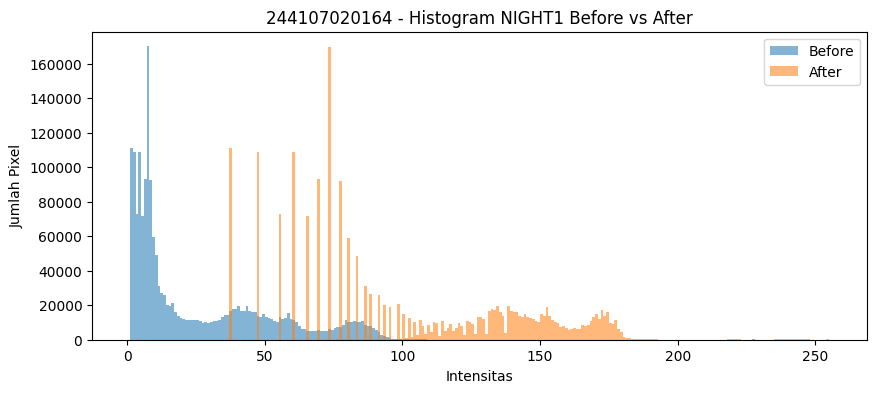

Metode yang dipilih : Gamma Correction
Gamma terbaik       : 2.9
Alasan: Gamma Correction menaikkan midtone citra gelap secara nonlinier sehingga detail gelap lebih terlihat tanpa menambahkan brightness yang sama pada seluruh pixel.
Risiko: gamma terlalu besar dapat membuat citra washed-out, memperjelas noise sensor, dan menyebabkan detail highlight hilang karena clipping.


In [22]:
night = read_bgr('NIGHT1.jpg')

# Metode dipilih: Gamma Correction.
# Parameter diuji bertahap dan nilai terbaik ditentukan dari detail, brightness, dan clipping.
gamma_night = np.round(np.arange(1.10, 3.05, 0.15), 2)

night_rows = []
night_results = []

for g in gamma_night:
    corrected = gamma_correction(night, float(g))
    gray = cv.cvtColor(corrected, cv.COLOR_BGR2GRAY)

    mean = float(gray.mean())
    std = float(gray.std())
    edges = edge_score(corrected)
    clipping = clip_percent(corrected)

    # Citra malam diangkat menuju midtone, tetap mempertahankan detail dan clipping rendah.
    score = (
        edges * (1 - clipping/100.0)
        / (1 + abs(mean - 105.0)/105.0)
    )

    night_results.append(corrected)
    night_rows.append([g, mean, std, edges, clipping, score])

df_night = pd.DataFrame(
    night_rows,
    columns=['Gamma', 'Mean', 'Std', 'Edge Score', 'Clipping (%)', 'Skor']
)

best_idx = df_night['Skor'].idxmax()
best_gamma_night = float(df_night.loc[best_idx, 'Gamma'])
night_best = night_results[best_idx]

show_grid(
    [night, night_best],
    ['Before', f'After - Gamma {best_gamma_night}'],
    cols=2,
    figsize=(13,5)
)

display(df_night.sort_values('Skor', ascending=False).head(10))

before_gray = cv.cvtColor(night, cv.COLOR_BGR2GRAY)
after_gray = cv.cvtColor(night_best, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10,4))
plt.hist(before_gray.ravel(), bins=256, range=(0,256), alpha=0.55, label='Before')
plt.hist(after_gray.ravel(), bins=256, range=(0,256), alpha=0.55, label='After')
plt.title(NIM + ' - Histogram NIGHT1 Before vs After')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')
plt.legend()
plt.show()

print('Metode yang dipilih : Gamma Correction')
print('Gamma terbaik       :', best_gamma_night)
print(
    'Alasan: Gamma Correction menaikkan midtone citra gelap secara nonlinier sehingga detail gelap '
    'lebih terlihat tanpa menambahkan brightness yang sama pada seluruh pixel.'
)
print(
    'Risiko: gamma terlalu besar dapat membuat citra washed-out, memperjelas noise sensor, '
    'dan menyebabkan detail highlight hilang karena clipping.'
)

## Kesimpulan

Praktikum menunjukkan perbedaan penting antara operasi aritmatika `uint8` biasa dan operasi saturasi. Pada citra pribadi, inverse, contrast, linear/logarithmic brightness, grayscale, gamma correction, kuantisasi bit, average denoising, dan logical masking menghasilkan perubahan yang dapat diukur dari distribusi intensitas, clipping, detail tepi, serta PSNR. Parameter berbasis NIM membuat hasil transformasi berbeda untuk setiap mahasiswa.